In [1]:
import openmc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.colors import LogNorm

import numpy as np

In [2]:
with openmc.StatePoint('3pcm_error_statepoint.h5') as sp:
    box_1_tally = sp.get_tally(name = 'box 1 power')
    box_2_tally = sp.get_tally(name = 'box 2 power')
    box_3_tally = sp.get_tally(name = 'box 3 power')
    box_4_tally = sp.get_tally(name = 'box 4 power')
    box_5_tally = sp.get_tally(name = 'box 5 power')
    box_6_tally = sp.get_tally(name = 'box 6 power')
    generation_time_tally = sp.get_tally(name = 'generation time')
print(box_1_tally, box_2_tally, box_3_tally, box_4_tally, box_5_tally, box_6_tally, generation_time_tally)

Tally
	ID             =	1
	Name           =	box 1 power
	Filters        =	MeshFilter
	Nuclides       =	total
	Scores         =	['fission', 'flux', 'fission-q-recoverable']
	Estimator      =	tracklength
	Multiply dens. =	True Tally
	ID             =	2
	Name           =	box 2 power
	Filters        =	MeshFilter
	Nuclides       =	total
	Scores         =	['fission', 'flux', 'fission-q-recoverable']
	Estimator      =	tracklength
	Multiply dens. =	True Tally
	ID             =	3
	Name           =	box 3 power
	Filters        =	MeshFilter
	Nuclides       =	total
	Scores         =	['fission', 'flux', 'fission-q-recoverable']
	Estimator      =	tracklength
	Multiply dens. =	True Tally
	ID             =	4
	Name           =	box 4 power
	Filters        =	MeshFilter
	Nuclides       =	total
	Scores         =	['fission', 'flux', 'fission-q-recoverable']
	Estimator      =	tracklength
	Multiply dens. =	True Tally
	ID             =	5
	Name           =	box 5 power
	Filters        =	MeshFilter
	Nuclides      

In [3]:
box_1_score = box_1_tally.get_slice(scores = ['fission-q-recoverable'])
box_2_score = box_2_tally.get_slice(scores = ['fission-q-recoverable'])
box_3_score = box_3_tally.get_slice(scores = ['fission-q-recoverable'])
box_4_score = box_4_tally.get_slice(scores = ['fission-q-recoverable'])
box_5_score = box_5_tally.get_slice(scores = ['fission-q-recoverable'])
box_6_score = box_6_tally.get_slice(scores = ['fission-q-recoverable'])
velocity = generation_time_tally.get_slice(scores = ['inverse-velocity'])
flux = generation_time_tally.get_slice(scores = ['flux'])
absorption = generation_time_tally.get_slice(scores = ['absorption'])

In [4]:
MFP = 29 #cm
generation_time = ((velocity.mean / 100) * MFP) 
print(f"{generation_time[0][0][0] * 1e6:.3f}")
print(absorption.mean)

198.789
[[[1.00009929]]]


In [4]:
import math
sigma_f = 0.2511178522600108
sigma_w = 0.00808248675139869
sigma_g = 0.0003493186021889106
sigma_c = 2.499466010579727
t_d = ((math.sqrt(math.pi)) * velocity.mean[0][0][0] / (2 * (sigma_f + sigma_w + sigma_g + sigma_c)))
print(f'{t_d}')
print(velocity.mean)

0.0002201832085395044
[[[0.00068548]]]


In [5]:
import math
sigma = absorption.mean[0][0][0] / flux.mean[0][0][0]
t_d = ((math.sqrt(math.pi)) * velocity.mean[0][0][0] / (2 * sigma))
print(f'{t_d}')

0.16921635321637893


In [6]:
box_1_score.mean.shape = (2,2,1)
box_2_score.mean.shape = (2,2,1)
box_3_score.mean.shape = (2,2,1)
box_4_score.mean.shape = (2,2,1)
box_5_score.mean.shape = (2,2,1)
box_6_score.mean.shape = (2,2,1)

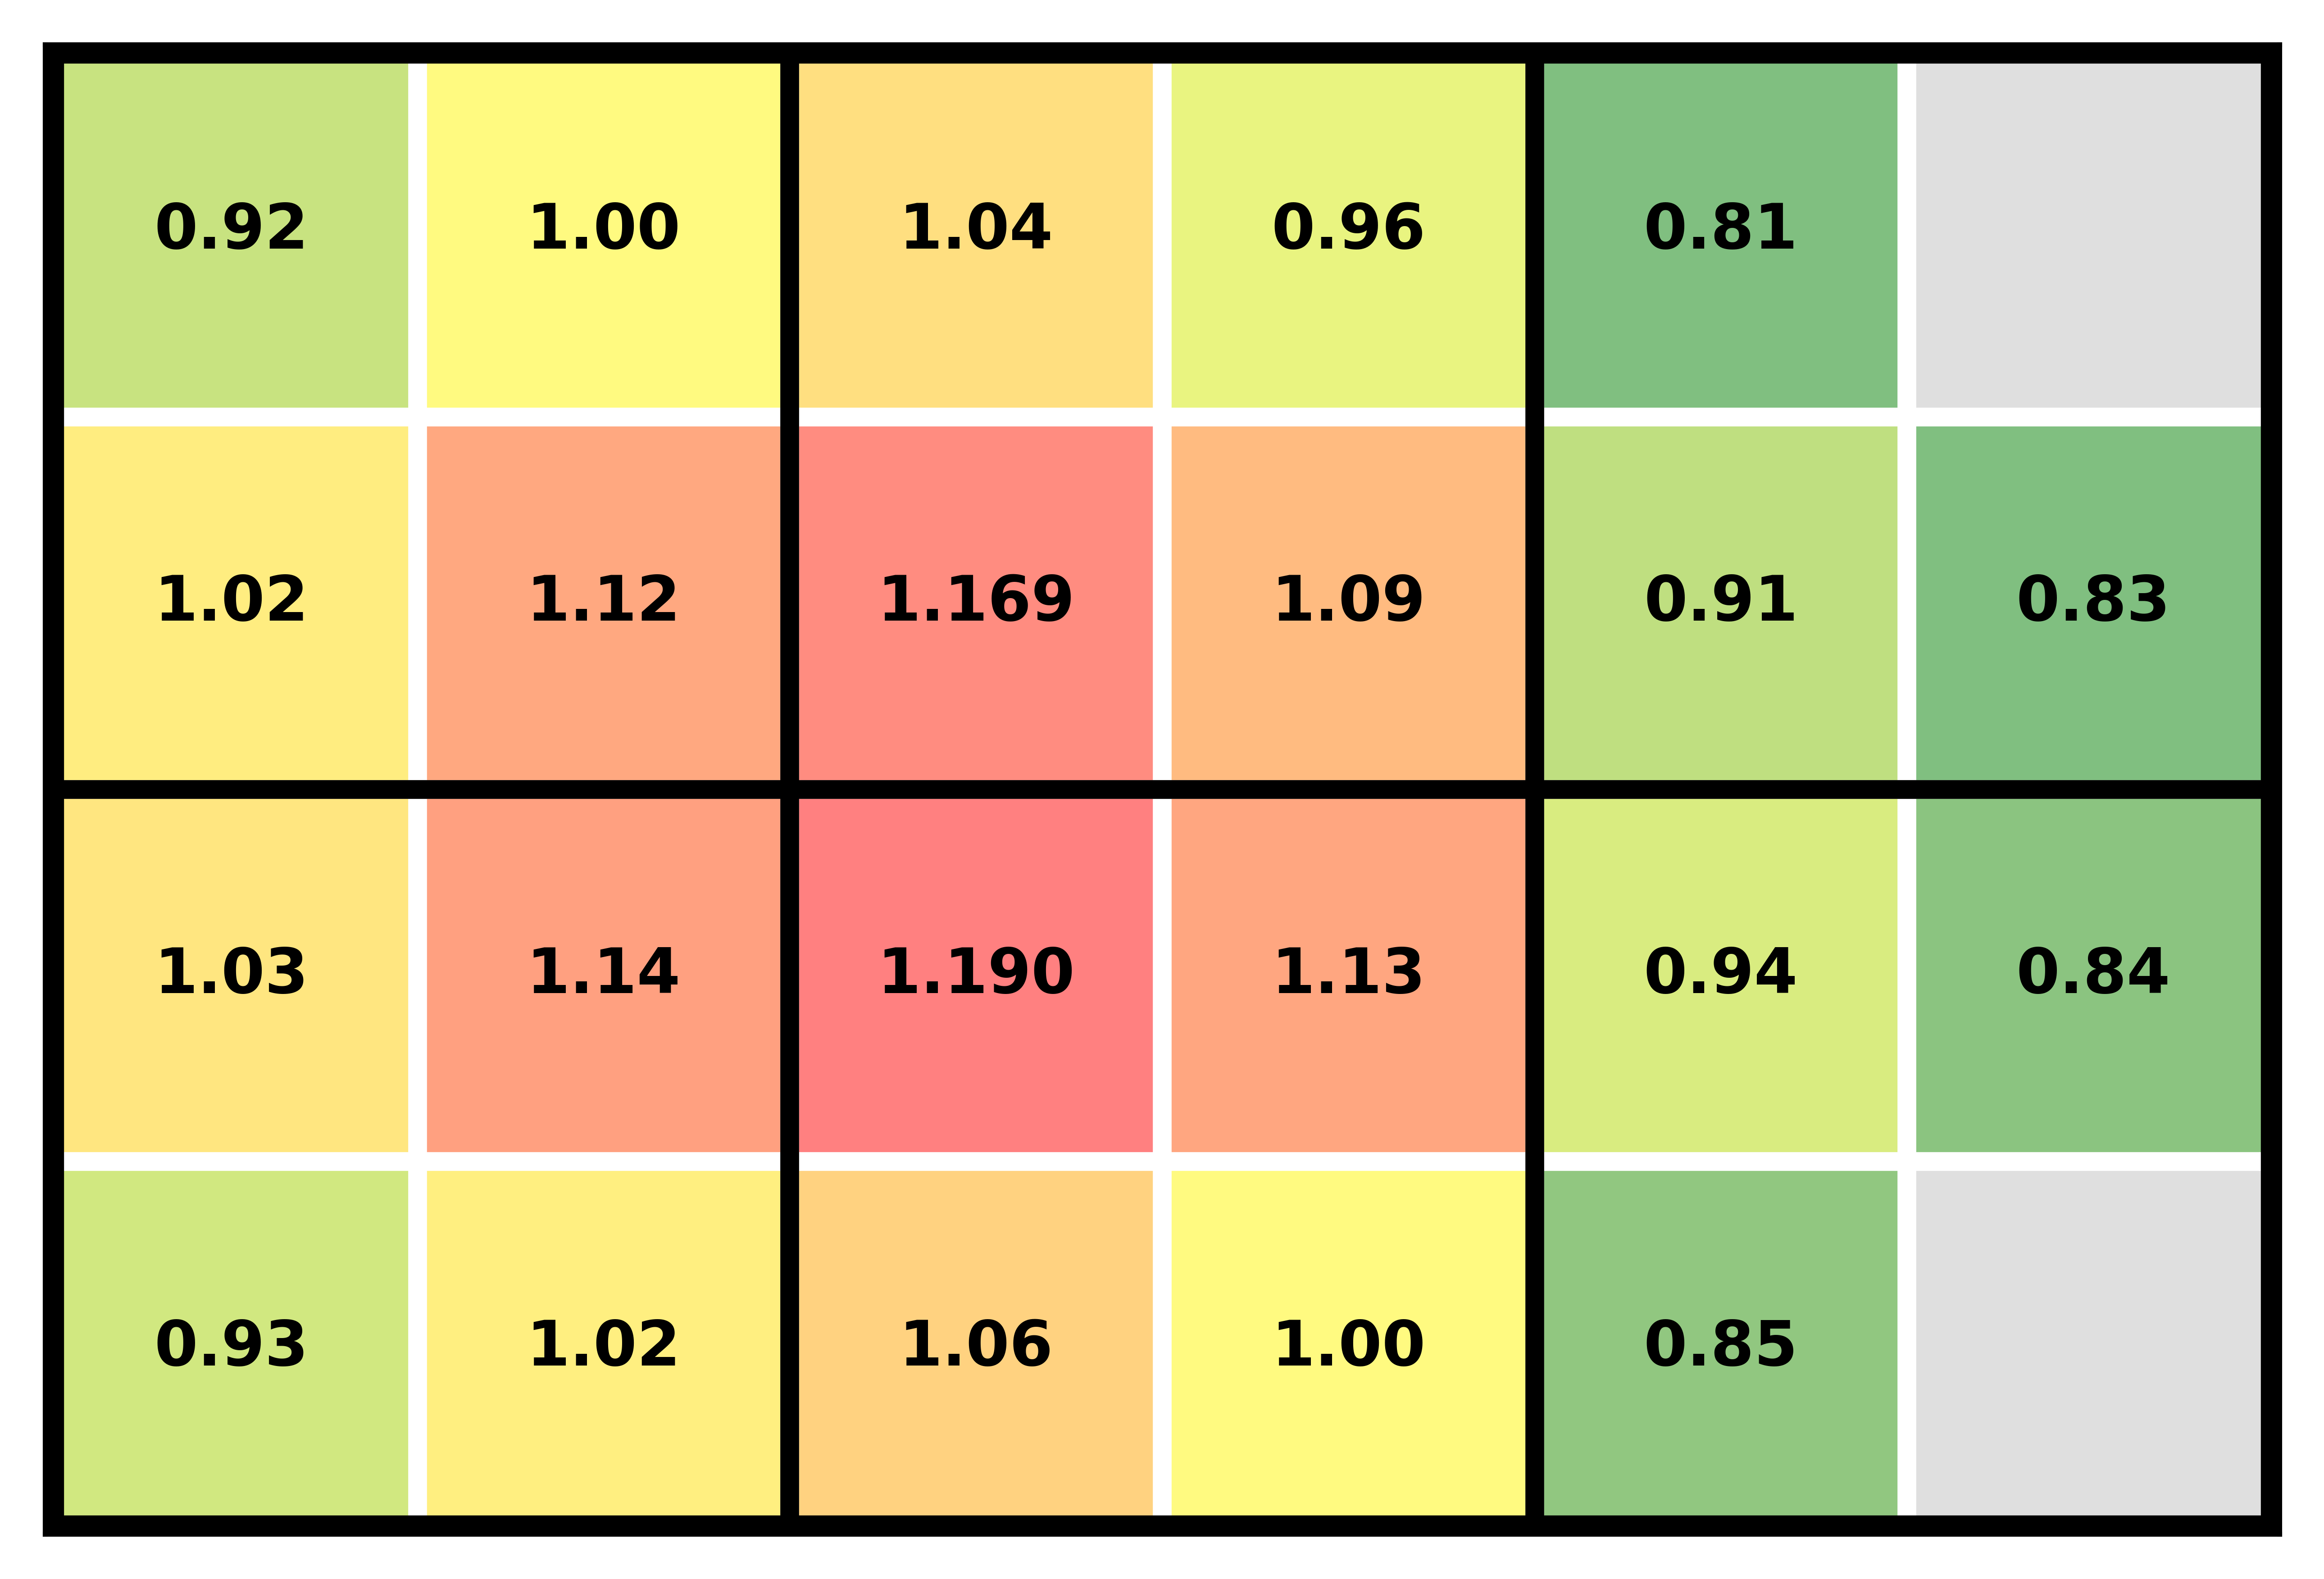

In [7]:
from matplotlib.colors import LinearSegmentedColormap, LogNorm

def flip_assemblies(grid):
    return np.array([[grid[1,0], grid[1,1]],   
                     [grid[0,0], grid[0,1]]]) 

grids = []
for box in [box_1_score, box_2_score, box_3_score, box_4_score, box_5_score, box_6_score]:
    grid = box.mean[:,:,0] if box.mean.shape[-1] == 1 else box.mean
    grid_flipped = flip_assemblies(grid)
    grids.append(grid_flipped)

bottom_row = np.hstack((grids[0], grids[1], grids[2]))  
top_row    = np.hstack((grids[3], grids[4], grids[5]))  

assemblies_array = np.vstack((top_row, bottom_row))
nonzero_assemblies = assemblies_array[assemblies_array > 0]
core_average = np.mean(nonzero_assemblies)
peaking_factors = (assemblies_array / core_average)

masked_peaking = np.ma.masked_where(peaking_factors == 0, peaking_factors)


cmap = LinearSegmentedColormap.from_list("custom_cmap", ["green", "yellow", "red"])


cmap.set_bad(color='silver')

fig, ax = plt.subplots(dpi=1000)

cax = ax.imshow(
    masked_peaking, 
    cmap=cmap, 
    norm=LogNorm(vmin=0.83, vmax=1.19), 
    interpolation='nearest', 
    alpha=0.5
)




for i in range(1, 6):  
    ax.axvline(x=i - 0.5, color='white', linestyle='-', linewidth=3)  
for i in range(1, 4):  
    ax.axhline(y=i - 0.5, color='white', linestyle='-', linewidth=3) 

# Thick black lines for special boundaries
middle_row = peaking_factors.shape[0] / 2
ax.axhline(y=middle_row - 0.5, color='black', linestyle='-', linewidth=3)

one_third = peaking_factors.shape[1] / 3
two_thirds = 2 * one_third
ax.axvline(x=one_third - 0.5, color='black', linestyle='-', linewidth=3)  
ax.axvline(x=two_thirds - 0.5, color='black', linestyle='-', linewidth=3)

ax.axhline(y=-0.5, color='black', linewidth=6)  
ax.axhline(y=peaking_factors.shape[0] - 0.5, color='black', linewidth=6)  
ax.axvline(x=-0.5, color='black', linewidth=6)  
ax.axvline(x=peaking_factors.shape[1] - 0.5, color='black', linewidth=6)

# Annotate cell values
for i in range(peaking_factors.shape[0]):
    for j in range(peaking_factors.shape[1]):
        if peaking_factors[i, j] == 0:
            ax.text(j, i, f'', ha='center', va='center', color='black', fontsize=12, alpha=1)
        if 0 < peaking_factors[i, j] < 1.15:
            ax.text(j, i, f'{peaking_factors[i, j]:.2f}', ha='center', va='center', color='black', fontsize=10, alpha=1, fontweight='bold')
        if 1.15 < peaking_factors[i, j]:
            ax.text(j, i, f'{peaking_factors[i, j]:.3f}', ha='center', va='center', color='black', fontsize=10, alpha=1, fontweight='bold')

ax.set_xticks([])
ax.set_yticks([])

plt.show()